<a href="https://colab.research.google.com/github/SergeiVKalinin/MSE_Spring_2026/blob/main/Module%202/9_Automated_pySR_Gpax_test_functions_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Illustarting symbolic regression integration with structured Gaussian Processesfor MSE 510/420 class
- Notebook by Utkarsh Pratiush, https://scholar.google.com/citations?hl=en&user=BqhnGGAAAAAJ&view_op=list_works&sortby=pubdate
- Instructor Sergei V. Kalinin

In [1]:
!pip install pysr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.7/251.7 kB 12.0 MB/s eta 0:00:00


In [2]:
!pip install gpax
!pip install arviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.0/78.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.3/374.3 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.4/172.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 384.1/384.1 kB 18.7 MB/s eta 0:00:00


# Simulated data

# PySR

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Define the functions
def forrester(x, noise = 0.0):
    # Commonly used interval for Forrester
    return (6*x - 2)**2 * np.sin(12*x - 4) + noise * np.random.randn(len(x))

def ackley_1d(x, a=20, b=0.2, c=2*np.pi, noise = 0.01):
    # Typical interval is large, but interesting features are within this range
    return -a * np.exp(-b * np.sqrt(x**2)) - np.exp(np.cos(c * x)) + a + np.exp(1) + noise * np.random.randn(len(x))

def rastrigin_1d(x, noise = 0.01):
    A = 10
    # Rastrigin's interesting features are well represented in this range
    return A + (x**2 - A * np.cos(2 * np.pi * x))  + noise * np.random.randn(len(x))

def schwefel_1d(x, noise = 0.01):
    # Schwefel shows its characteristic shape well in this interval
    return 418.9829 - x * np.sin(np.sqrt(np.abs(x)))  + noise * np.random.randn(len(x))

def sin_function(x, noise = 0.01):
    # Sine function is periodic, so showing a few periods is sufficient
    return np.sin(x) +  noise * np.random.randn(len(x))

def branin_1d(x, noise = 0.01):
    # Branin is usually a 2D function, adapted here; interval chosen for illustration
    y = x
    a = 1
    b = 5.1 / (4*np.pi**2)
    c = 5 / np.pi
    r = 6
    s = 10
    t = 1 / (8*np.pi)
    return a*(y - b*x**2 + c*x - r)**2 + s*(1-t)*np.cos(x) + s + noise * np.random.randn(len(x)) +  noise * np.random.randn(len(x))



In [4]:
fn_list = [forrester, ackley_1d, rastrigin_1d, schwefel_1d, sin_function, branin_1d]

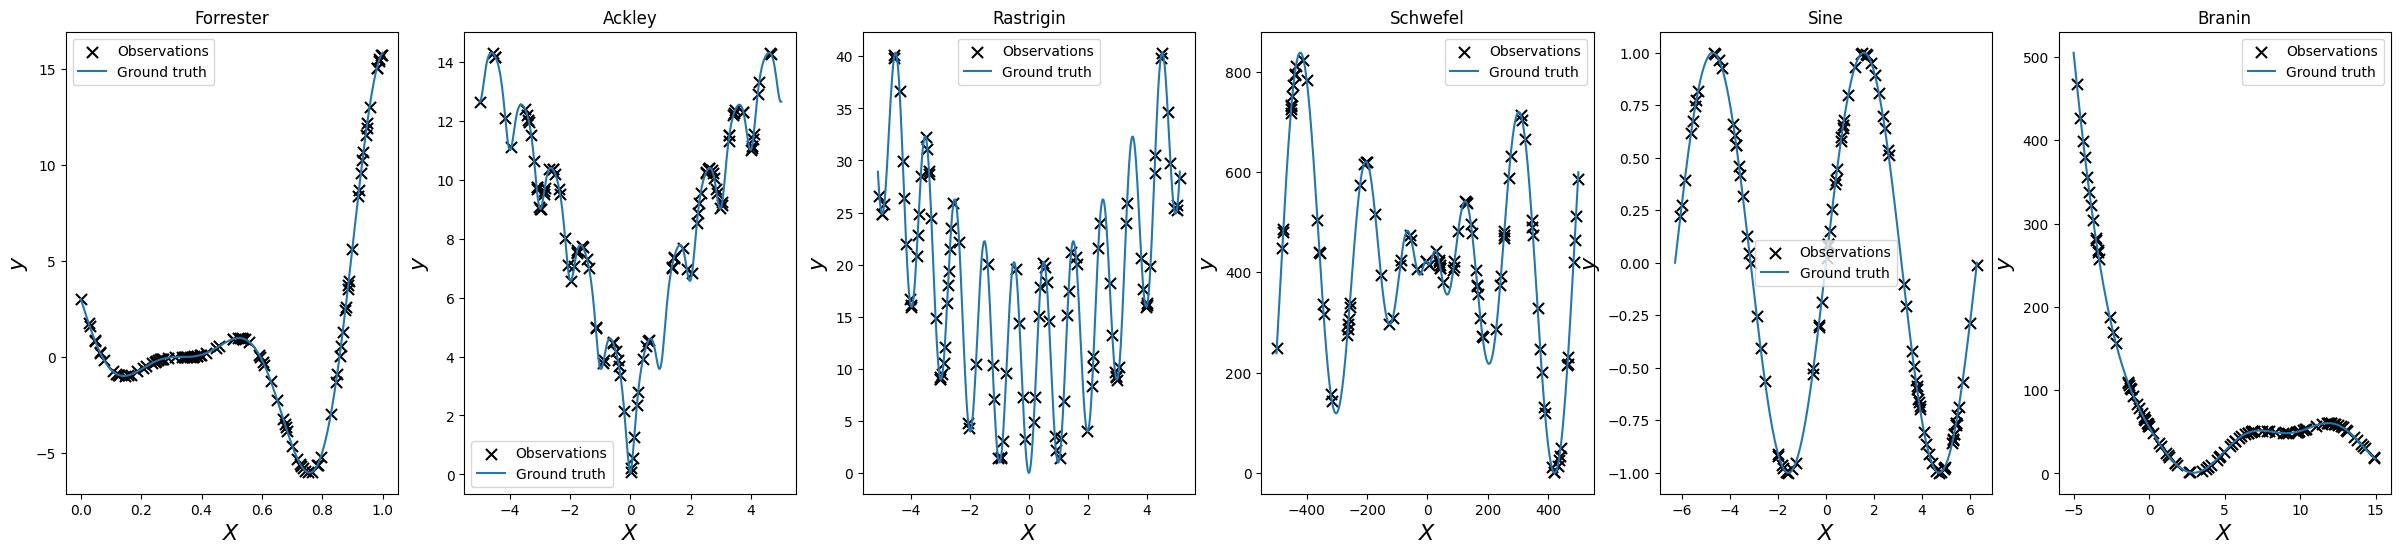

In [5]:
#X_bounds = np.array([0, 10])
#X_unmeasured = np.linspace(X_bounds[0], X_bounds[1], 200)

fig, ax = plt.subplots(1, len(fn_list), dpi=100, figsize=(30, 6))

y_measured_list = []
ground_truth_list = []
X_measured_list = []
X_unmeasured_list = []

titles = ['Forrester', 'Ackley', 'Rastrigin', 'Schwefel', 'Sine', 'Branin']
x_ranges_list = [np.linspace(0, 1, 400), np.linspace(-5, 5, 400), np.linspace(-5.12, 5.12, 400),
            np.linspace(-500, 500, 400), np.linspace(-2*np.pi, 2*np.pi, 400), np.linspace(-5, 15, 400)]


# Create plots with optimal intervals
for i,(fn, x_range )in enumerate(zip(fn_list, x_ranges_list)):
  X_measured_list.append(np.sort(np.random.uniform(x_range[0], x_range[-1], size=(100,))))
  X_unmeasured_list.append(x_range)
  y_measured = fn(X_measured_list[-1], noise = 0)
  ground_truth = fn(X_unmeasured_list[-1], noise=0)



  ax[i].set_xlabel("$X$", fontsize=16)
  ax[i].set_ylabel("$y$", fontsize=16)
  ax[i].scatter(X_measured_list[-1], y_measured, marker='x', c='k', s=64, zorder=1, label="Observations", alpha=1.0)
  ax[i].plot(X_unmeasured_list[-1], ground_truth, label='Ground truth')
  ax[i].legend(loc='best')
  ax[i].set_title(titles[i])

  y_measured_list.append(y_measured)
  ground_truth_list.append(ground_truth)

## PySR Fit

In [6]:
from pysr import PySRRegressor

[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/juliacall/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/juliapkg/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/pysr/juliapkg.json
[juliapkg] Locating Julia 1.10.3 - 1.11
[juliapkg] Using Julia 1.11.5 at /usr/local/bin/julia
[juliapkg] Using Julia project at /root/.julia/environments/pyjuliapkg
[juliapkg] Writing Project.toml:
           | [deps]
           | PythonCall = "6099a3de-0909-46bc-b1f4-468b9a2dfc0d"
           | OpenSSL_jll = "458c3c95-2e84-50aa-8efc-19380b2a3a95"
           | SymbolicRegression = "8254be44-1295-4e6a-a16d-46603ac705cb"
           | Serialization = "9e88b42a-f829-5b0c-bbe9-9e923198166b"
           | 
           | [compat]
           | PythonCall = "=0.9.26"
           | OpenSSL_jll = "~3.0"
           | SymbolicRegression = "~1.11"
           | Serialization = "^1"
[juliapkg] Installing packages:
           | impo

In [7]:
#fn_list = [rastrigin_1d]

In [8]:
titles

['Forrester', 'Ackley', 'Rastrigin', 'Schwefel', 'Sine', 'Branin']

In [9]:
models_dict = {}

for i in range(len(titles)):
  # Initialize PySR with some parameters
  print(i, titles[i])

  model = PySRRegressor(
      niterations=5,
      binary_operators=["+", "*", "/", "-"],
      unary_operators=["sin", "cos", "exp", "log"],
      # model_selection="best",
      verbosity=1 )

  model.fit(X_measured_list[i].reshape(-1,1), y_measured_list[i].reshape(-1,1))
  models_dict[titles[i]] = model

/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
INFO:pysr.sr:Compiling Julia backend...


0 Forrester


[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.819e+01  0.000e+00  y = 1.3588
2           2.580e+01  8.839e-02  y = exp(x₀)
3           2.469e+01  4.400e-02  y = x₀ * 3.7176
4           2.399e+01  2.891e-02  y = x₀ * exp(x₀)
5           2.037e+01  1.635e-01  y = exp(x₀ / cos(x₀))
6           1.056e+01  6.571e-01  y = x₀ / (0.05792 - log(x₀))
8           8.934e+00  8.359e-02  y = (x₀ / (0.04384 - log(x₀))) - x₀
10          6.771e+00  1.386e-01  y = exp(((x₀ - -11.601) * x₀) - 4.5263) * 0.0055282
12          6.654e+00  8.762e-03  y = exp(((x₀ - -2.1066) * (x₀ * 3.6526)) - 6.4276) * 0.141...
                                      82
17          4.768e+00  6.665e-02  y = x₀ * (exp((x₀ + x₀) * (log((x₀ * x₀) + x₀) * 2.2977)) ...
                                      + -4.5128)
19          4.761e+00  6.969e-04  y = ((((exp(exp(x₀ * (x₀ * 1.2103)) * x₀) - 8.1173) * x₀) ...
            

/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:
/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


...

  - outputs/20260223_111915_rfH7Rg/hall_of_fame.csv
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           3.824e+04  0.000e+00  y = 423.09
4           3.823e+04  -0.000e+00  y = 423.09 + cos(x₀)
5           3.023e+04  2.321e-01  y = (x₀ * -0.28815) + 429.72
8           3.023e+04  -0.000e+00  y = ((x₀ * -0.28847) + 429.73) - cos(x₀)
12          3.010e+04  5.662e-04  y = (((x₀ + -48.624) * -0.28632) - (-0.75956 / sin(x₀))) +...
                                       416.71
14          2.982e+04  3.737e-03  y = ((x₀ + (9.3314 / sin((x₀ / -323.26) + -0.34202))) * -0...
                                      .30317) + 430.68
15          2.851e+04  4.262e-02  y = (((x₀ + -297.78) * -0.28811) - ((x₀ / (x₀ + -416.32)) ...
                                      - 115.61)) - -235.76
17          2.754e+04  1.632e-02  y = (((x₀ + -3.6293) * -0.1768) - (9.4579 / (((x₀ - -221.2...
                     

[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:
/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


  - outputs/20260223_111918_93KTtw/hall_of_fame.csv
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           4.858e-01  0.000e+00  y = -0.076304
2           4.467e-15  3.232e+01  y = sin(x₀)
4           4.466e-15  1.054e-04  y = sin(x₀) + 4.0745e-10
8           4.459e-15  4.237e-04  y = (4.0745e-10 * (x₀ * -1.4864)) + sin(x₀)
9           4.457e-15  4.990e-04  y = ((4.0745e-10 * x₀) * sin(-1.4864)) + sin(x₀)
12          4.444e-15  9.266e-04  y = ((x₀ * ((x₀ / -1.0375) * 5.9186e-11)) / -0.23953) + si...
                                      n(x₀)
15          4.440e-15  3.041e-04  y = (4.0745e-10 * (((x₀ / (-0.5269 / 0.54695)) * x₀) / sin...
                                      (-1.4864))) + sin(x₀)
23          4.361e-15  2.256e-03  y = ((1.6814e-09 / sin(sin((sin((0.16191 - sin(x₀ + 0.0012...
                                      542)) + 0.53899) - sin(x₀)) + 0.76059))) - -1) * sin(x₀)
────

[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:
/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


  - outputs/20260223_111920_oScqiY/hall_of_fame.csv
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.057e+04  0.000e+00  y = 88.047
3           9.870e+03  3.373e-02  y = 92.704 - x₀
4           3.479e+03  1.042e+00  y = exp(1.6942 - x₀)
6           1.132e+03  5.614e-01  y = exp((x₀ * -0.42615) + 4.1227)
8           3.415e+02  5.990e-01  y = exp((x₀ * -0.56483) + 3.4413) + 36.577
10          2.782e+02  1.025e-01  y = exp((x₀ * -0.53528) + 3.6039) + (x₀ - -28.208)
12          1.981e+02  1.697e-01  y = (exp((x₀ * -0.45192) + 4.0708) - (x₀ * -4.1678)) + -0....
                                      037657
14          1.512e+02  1.353e-01  y = x₀ + ((exp((x₀ * -0.27629) + 3.5735) * (x₀ * -0.68457)...
                                      ) + 52.711)
17          1.067e+02  1.161e-01  y = (x₀ * ((exp((x₀ * -0.27959) + 3.2871) + sin(x₀ * -1.19...
                                      35))

In [10]:
models_dict

{'Forrester': PySRRegressor.equations_ = [
 	    pick     score                                           equation  \
 	0         0.000000                                           1.358802   
 	1         0.088394                                            exp(x0)   
 	2         0.044005                                     x0 * 3.7175624   
 	3         0.028909                                       x0 * exp(x0)   
 	4         0.163503                                  exp(x0 / cos(x0))   
 	5         0.657133                       x0 / (0.057919882 - log(x0))   
 	6         0.083589                (x0 / (0.043839924 - log(x0))) - x0   
 	7         0.138556  exp(((x0 - -11.600696) * x0) - 4.5263095) * 0....   
 	8         0.008762  exp(((x0 - -2.1065784) * (x0 * 3.6526098)) - 6...   
 	9         0.066648  x0 * (exp((x0 + x0) * (log((x0 * x0) + x0) * 2...   
 	10        0.000697  ((((exp(exp(x0 * (x0 * 1.2103)) * x0) - 8.1173...   
 	11  >>>>  0.220336  ((((x0 * x0) * (exp((x0 + 3.7365878

In [11]:
models_dict[titles[1]]

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                            8.66104   
	1         0.110632                                 8.471203 - cos(x0)   
	2         0.180324                      exp(exp(cos(1.3352882 / x0)))   
	3         0.505780                  exp(exp(sin(cos(0.739988 / x0))))   
	4         0.224037         exp(exp(cos(-1.044055 / x0))) + -1.5905817   
	5         0.236852    exp(1.309948 - cos(x0 / -1.2988073)) + 3.182907   
	6         0.097732  exp(cos(-2.1848211 / (x0 / sin(x0 * 0.76825625...   
	7         0.018213  exp(cos(-0.54500425 - (1.3134072 / (x0 / sin(x...   
	8         0.034546  ((exp(cos(cos(x0 * 0.25162786))) + 4.1249976) ...   
	9   >>>>  0.211321  ((((exp(cos(cos(x0))) + 4.1249976) * exp(cos(c...   
	10        0.094163  exp((((x0 / (((((-0.8238189 / x0) + (x0 * -0.0...   
	11        0.020275  ((exp(cos(cos((-0.9911573 / 0.32174227) * x0))...   
	12        0.030051  (-3.6837974 - cos(x0)) + ((cos(exp(cos(cos(cos...   
	13        0.180178  (((exp(cos(cos((-0.9911573 / 0.32174227) * x0)...   
	
	         loss  complexity  
	0   11.511214           1  
	1    8.260010           4  
	2    5.759081           6  
	3    3.472927           7  
	4    2.775859           8  
	5    2.190452           9  
	6    1.633806          12  
	7    1.519014          16  
	8    1.322968          20  
	9    1.070962          21  
	10   0.974720          22  
	11   0.935986          24  
	12   0.881388          26  
	13   0.736066          27  
]

## Parse Equations to Jax Format

In [12]:
pysr_eqn_dict = {}

for i,title in enumerate(titles):
  equations = models_dict[title].equations_
  equations_data = []
  for index, row in equations.iterrows():
      equation_data = {
          "equation": row['equation'],
          "score": row['loss']
      }
      equations_data.append(equation_data)
  pysr_eqn_dict[f"{title}"] = equations_data


In [13]:
pysr_eqn_dict

{'Forrester': [{'equation': '1.358802', 'score': 28.18954},
  {'equation': 'exp(x0)', 'score': 25.804716},
  {'equation': 'x0 * 3.7175624', 'score': 24.693802},
  {'equation': 'x0 * exp(x0)', 'score': 23.99014},
  {'equation': 'exp(x0 / cos(x0))', 'score': 20.371553},
  {'equation': 'x0 / (0.057919882 - log(x0))', 'score': 10.559291},
  {'equation': '(x0 / (0.043839924 - log(x0))) - x0', 'score': 8.933674},
  {'equation': 'exp(((x0 - -11.600696) * x0) - 4.5263095) * 0.005528202',
   'score': 6.7714467},
  {'equation': 'exp(((x0 - -2.1065784) * (x0 * 3.6526098)) - 6.427568) * 0.14182165',
   'score': 6.653813},
  {'equation': 'x0 * (exp((x0 + x0) * (log((x0 * x0) + x0) * 2.2976813)) + -4.5128393)',
   'score': 4.7681084},
  {'equation': '((((exp(exp(x0 * (x0 * 1.2103)) * x0) - 8.117338) * x0) + 1.7953372) * x0) - x0',
   'score': 4.761465},
  {'equation': '((((x0 * x0) * (exp((x0 + 3.7365878) * x0) + 2.538041)) * (x0 + -0.8174028)) - x0) + 0.06992775',
   'score': 3.8198807},
  {'equati

In [14]:
def convert_to_jax_format(equations_data):
    # Initialize parameter names generator
    def param_names_gen():
        for i in range(26):  # Limit to 26 for simplicity, adjust if more needed
            yield chr(97 + i)  # Generates 'a', 'b', 'c', ...

    modified_equations = []
    param_gen = param_names_gen()

    for item in equations_data:
        equation = item['equation']
        sympy_eq = sp.sympify(equation, evaluate=False)



        # Convert sympy expression to string and replace math functions with jnp equivalents
        jax_eq_str = str(sympy_eq)
        jax_eq_str = jax_eq_str.replace("sin", "jnp.sin").replace("cos", "jnp.cos").replace("exp", "jnp.exp").replace("log", "jnp.log")

        # Replace 'x0' with 'x' for consistency
        jax_eq_str = jax_eq_str.replace("x0", "x")

        modified_equations.append(jax_eq_str)

    return modified_equations

In [15]:
import sympy as sp

In [16]:
# iterate through dict:
converted_equations_dict = {}
for i,title in enumerate(titles):
  eqn_list_temp = pysr_eqn_dict[f"{title}"]
  converted_equations_dict[f"{title}"]  = convert_to_jax_format(eqn_list_temp)


In [17]:
converted_equations_dict

{'Forrester': ['1.35880200000000',
  'jnp.exp(x)',
  'x*3.7175624',
  'x*jnp.exp(x)',
  'jnp.exp(x/jnp.cos(x))',
  'x/(0.057919882 - jnp.log(x))',
  '-x + x/(0.043839924 - jnp.log(x))',
  'jnp.exp(x*(x - 1*(-11.600696)) - 1*4.5263095)*0.005528202',
  'jnp.exp((x - 1*(-2.1065784))*x*3.6526098 - 1*6.427568)*0.14182165',
  'x*(jnp.exp((x + x)*jnp.log(x*x + x)*2.2976813) - 4.5128393)',
  'x*(x*(jnp.exp(x*jnp.exp(x*x*1.2103)) - 1*8.117338) + 1.7953372) - x',
  'x*x*(x - 0.8174028)*(jnp.exp(x*(x + 3.7365878)) + 2.538041) - x + 0.06992775',
  '(x*(x*x*x*jnp.exp(x*jnp.exp(x)) - 1*6.2503214) - (x - 1.5616684) + 0.7760364)*x*2.047511',
  '(x*x*x*jnp.exp(x*jnp.exp(x)) - (x - 1.5616684) - (6.2503214*x + jnp.log(x)))*x*2.047511',
  '(x*(x*x*x*jnp.exp(x*jnp.exp(x)) - 1*6.414973) - (x - 1.5574151) + 1.3978093)*x*2.060248 - x',
  'x*x*x*(x/1.4269925 + x - (jnp.sin(jnp.exp(x)) + 0.77488905))*jnp.exp(x + x + 0.6285912)/0.36673388 + 0.6338292',
  'x*x*x*(x/1.739855 + x - (jnp.sin(jnp.exp(x)) + jnp.cos(x)

In [18]:
import re
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist

def define_functions_and_return_executables_specific_format(modified_equations, title):
    model_list = []
    model_prior_list = []

    # Function to extract numeric constants from the equation
    def find_constants(eq):
        # This regex finds all standalone numbers in the equation
        return set(re.findall(r'\b\d+\.?\d*|\.\d+\b', eq))

    # Generating parameter names sequentially
    def generate_param_names(start='a', count=26):
        for i in range(count):
            yield chr(ord(start) + i)



    for i, eq in enumerate(modified_equations, start=1):
        # Map x0 to x, x1 to y
        eq = eq.replace('x0', 'x').replace('x1', 'y')

        constants = find_constants(eq)

        param_name_gen = generate_param_names()
        param_map = {const: next(param_name_gen) for const in constants}

        # Replace constants in the equation with params dictionary access
        for const, param_name in param_map.items():
            eq = re.sub(r'\b' + const + r'\b', f'params["{param_name}"]', eq)

        # Define the model function
        func_name = f'{title}_guess_{i}'
        model_func_code = f"def {func_name}(x, params):\n    return {eq}\n"

        # Define the prior function with parameters
        prior_name = f'{func_name}_prior'
        prior_func_code = "def " + prior_name + "():\n    return {\n"
        for param_name in param_map.values():
            prior_func_code += f'        "{param_name}": numpyro.sample("{param_name}", dist.Normal(0, 1)),\n'
        prior_func_code += '    }\n'

        # Execute definitions
        print(i, model_func_code)

        try:
              exec(model_func_code, globals())
              exec(prior_func_code, globals())
              model_list.append(eval(func_name))
              model_prior_list.append(eval(prior_name))

        except:
          print(f"error{i}")




        # except Exception as e:
        #     # If there's an error, print the error message and then print "hi".
        #     print(f"Error: {e}")
        #     print("hi")




    return model_list, model_prior_list

# Example modified equations
# modified_equations = [
#     '5.18455',  # Constants will be replaced
#     'jnp.sin(x) - 5.034361',
#     '3.412044 + jnp.log(3.8652146 - 1.1082819) + jnp.sin(jnp.sin(0.08075898 + x) + x)',
# ]

#model_list, model_prior_list = define_functions_and_return_executables_specific_format(modified_equations)
# model_list, model_prior_list = define_functions_and_return_executables_specific_format(converted_equations)

# Now, model_list and model_prior_list contain the actual executable functions.


In [19]:
titles

['Forrester', 'Ackley', 'Rastrigin', 'Schwefel', 'Sine', 'Branin']

In [20]:
gpax_equations_dict = {}
for i,title in enumerate(titles):
  #if title == 'Rastrigin':
    eqn_list_temp = converted_equations_dict[f"{title}"]
    model_list, model_prior_list = define_functions_and_return_executables_specific_format(eqn_list_temp, title)
    gpax_equations_dict[f"{title}"]  = {"model_list": model_list, "model_prior_list": model_prior_list}

1 def Forrester_guess_1(x, params):
    return params["a"]

2 def Forrester_guess_2(x, params):
    return jnp.exp(x)

3 def Forrester_guess_3(x, params):
    return x*params["a"]

4 def Forrester_guess_4(x, params):
    return x*jnp.exp(x)

5 def Forrester_guess_5(x, params):
    return jnp.exp(x/jnp.cos(x))

6 def Forrester_guess_6(x, params):
    return x/(params["a"] - jnp.log(x))

7 def Forrester_guess_7(x, params):
    return -x + x/(params["a"] - jnp.log(x))

8 def Forrester_guess_8(x, params):
    return jnp.exp(x*(x - params["c"]*(-params["a"])) - params["c"]*params["b"])*params["d"]

9 def Forrester_guess_9(x, params):
    return jnp.exp((x - params["d"]*(-params["c"]))*x*params["e"] - params["d"]*params["b"])*params["a"]

10 def Forrester_guess_10(x, params):
    return x*(jnp.exp((x + x)*jnp.log(x*x + x)*params["a"]) - params["b"])

11 def Forrester_guess_11(x, params):
    return x*(x*(jnp.exp(x*jnp.exp(x*x*params["b"].2103)) - params["b"]*params["d"]) + params["a"]) - x



# Gpax on it

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import gpax
from scipy.optimize import curve_fit
import numpyro
from copy import deepcopy as dc
import jax.numpy as jnp
import arviz as az

In [22]:
# For github continuous integration
import os
if os.environ.get("CI_SMOKE"):
    NUM_WARMUP = 10
    NUM_SAMPLES = 10
else:
    NUM_WARMUP = 2000
    NUM_SAMPLES = 2000

In [23]:
model_list

[<function __main__.Branin_guess_1(x, params)>,
 <function __main__.Branin_guess_2(x, params)>,
 <function __main__.Branin_guess_3(x, params)>,
 <function __main__.Branin_guess_4(x, params)>,
 <function __main__.Branin_guess_5(x, params)>,
 <function __main__.Branin_guess_6(x, params)>,
 <function __main__.Branin_guess_7(x, params)>,
 <function __main__.Branin_guess_8(x, params)>,
 <function __main__.Branin_guess_9(x, params)>,
 <function __main__.Branin_guess_10(x, params)>]

0 Forrester
1 Ackley
2 Rastrigin
3 Schwefel
handling the functions===> Schwefel
model number 0


sample: 100%|██████████| 4000/4000 [16:50<00:00,  3.96it/s, 1023 steps of size 1.89e-04. acc. prob=0.69]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.36      0.00      0.36      0.36      0.37      4.16      1.49
k_length[0]     81.21      0.00     81.21     81.21     81.22      5.68      1.15
    k_scale  56407.75    296.24  56526.93  55922.05  56747.41      2.98      2.80
      noise      0.32      0.00      0.32      0.32      0.32      7.71      1.00



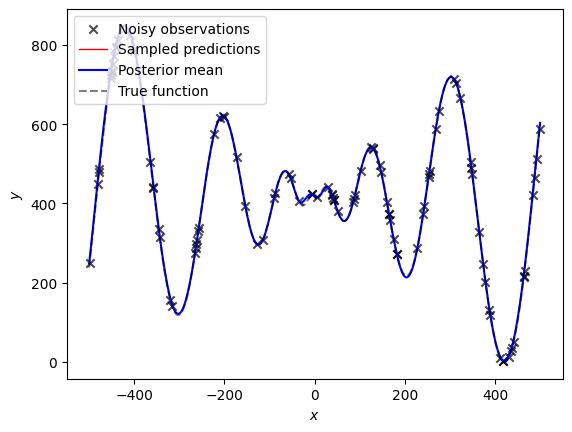

model number 1


sample: 100%|██████████| 4000/4000 [21:10<00:00,  3.15it/s, 1023 steps of size 1.23e-04. acc. prob=0.72]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      1.42      0.00      1.42      1.42      1.42      6.32      1.00
k_length[0]     92.65      0.00     92.65     92.65     92.65    154.10      1.01
    k_scale 103056.55    490.08 103073.89 102337.92 103799.72      3.17      2.10
      noise      0.42      0.00      0.42      0.42      0.42      4.06      1.25



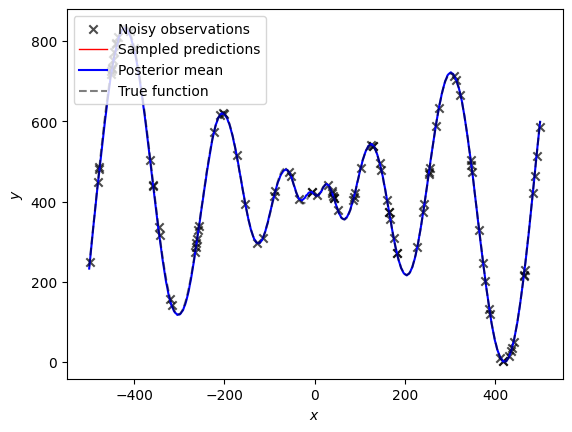

model number 2


sample: 100%|██████████| 4000/4000 [17:06<00:00,  3.90it/s, 19 steps of size 1.74e-04. acc. prob=0.71]  



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.97      0.00      0.97      0.97      0.97      8.77      1.03
          b     -0.13      0.00     -0.13     -0.13     -0.12      4.06      1.44
k_length[0]     86.97      0.00     86.97     86.97     86.97      6.58      1.70
    k_scale  69180.90    174.50  69157.59  68886.98  69463.37      8.12      1.00
      noise      0.30      0.00      0.30      0.30      0.30      6.50      1.24



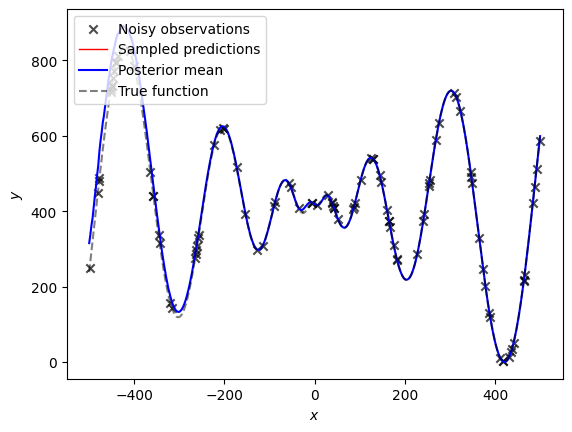

model number 3


sample: 100%|██████████| 4000/4000 [20:52<00:00,  3.19it/s, 3 steps of size 1.23e-04. acc. prob=0.72]   



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a     -0.22      0.00     -0.22     -0.23     -0.22      6.02      1.34
          b     -0.21      0.00     -0.21     -0.21     -0.20      4.29      1.42
k_length[0]     89.53      0.00     89.53     89.53     89.54      4.03      1.72
    k_scale  70434.23     80.67  70447.33  70302.62  70548.71     12.98      1.00
      noise      0.34      0.00      0.34      0.34      0.34      7.21      1.09



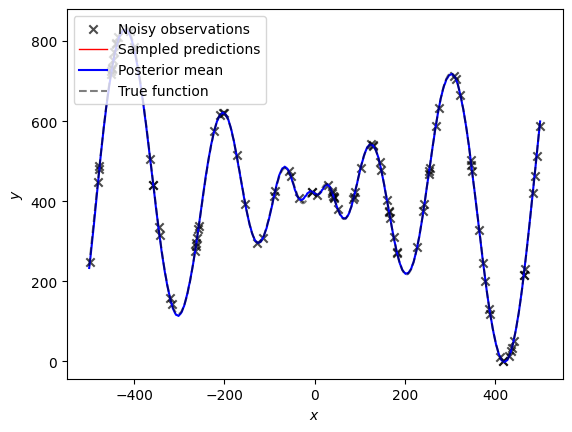

model number 4


sample: 100%|██████████| 4000/4000 [17:03<00:00,  3.91it/s, 16 steps of size 1.58e-04. acc. prob=0.80]  



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.04      0.00      0.04      0.03      0.05      3.22      1.82
          b      0.33      0.00      0.33      0.32      0.33     13.54      1.04
          c     -0.00      0.00     -0.00     -0.01      0.00      6.21      1.38
          d      0.23      0.00      0.23      0.23      0.24      4.36      1.00
          e     -0.66      0.00     -0.66     -0.66     -0.65      7.35      1.21
k_length[0]     91.87      0.00     91.87     91.86     91.87     12.38      1.00
    k_scale  67134.90    141.49  67149.23  66879.40  67353.88      4.12      1.62
      noise      0.32      0.00      0.32      0.32      0.32      4.73      1.04



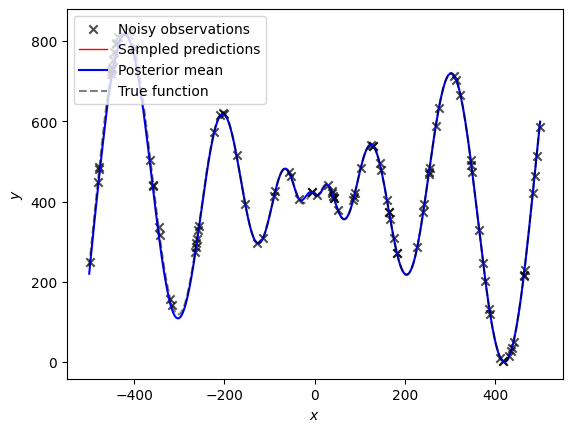

model number 5


sample: 100%|██████████| 4000/4000 [32:41<00:00,  2.04it/s, 1023 steps of size 1.61e-07. acc. prob=0.83]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.79      0.00      0.79      0.79      0.79       nan       nan
          b     -0.51      0.00     -0.51     -0.51     -0.51      1.00      1.00
          c      0.08      0.00      0.08      0.08      0.08      1.00      1.00
          d      0.21      0.00      0.21      0.21      0.21      1.00      1.00
          e      0.11      0.00      0.11      0.11      0.11      1.00      1.00
k_length[0]      1.12      0.00      1.12      1.12      1.12      1.00      1.00
    k_scale      1.23      0.00      1.23      1.23      1.23      1.00      1.00
      noise      0.89      0.00      0.89      0.89      0.89       nan       nan



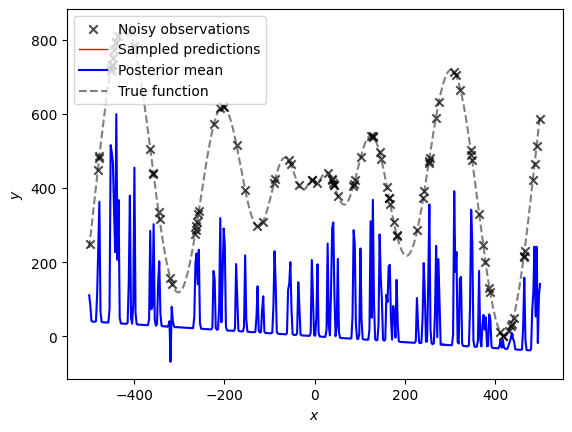

model number 6


sample: 100%|██████████| 4000/4000 [16:57<00:00,  3.93it/s, 1023 steps of size 1.75e-04. acc. prob=0.76]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.31      0.00      0.31      0.31      0.32      6.68      1.08
          b      0.23      0.00      0.23      0.22      0.23      4.24      1.65
          c     -0.48      0.01     -0.48     -0.49     -0.47      2.97      2.87
          d     -0.57      0.00     -0.57     -0.57     -0.57      5.14      1.67
          e     -0.65      0.00     -0.65     -0.66     -0.65      6.41      1.34
          f     -0.37      0.00     -0.37     -0.37     -0.37      8.00      1.02
k_length[0]     94.35      0.01     94.35     94.33     94.36     12.19      1.28
    k_scale  72531.59     93.72  72533.44  72399.51  72687.23     19.08      1.05
      noise      0.34      0.00      0.34      0.34      0.34      4.49      1.78



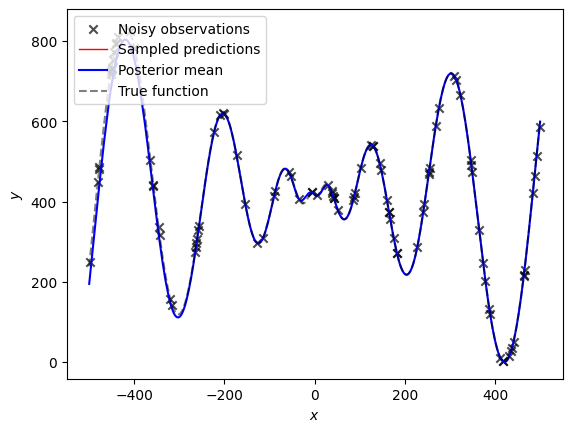

model number 7


sample: 100%|██████████| 4000/4000 [27:20<00:00,  2.44it/s, 1023 steps of size 5.60e-06. acc. prob=0.85]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.81      0.00      0.81      0.81      0.81      5.00      1.06
          b      0.62      0.00      0.62      0.62      0.62      6.23      1.53
          c      0.35      0.00      0.35      0.35      0.35      3.19      2.48
          d      0.28      0.00      0.28      0.28      0.28      4.87      1.08
          e     -0.56      0.00     -0.56     -0.56     -0.56      3.00      2.30
          f     -0.61      0.00     -0.61     -0.61     -0.61      4.27      1.54
          g      0.51      0.00      0.51      0.51      0.51      3.13      2.43
          h     -0.37      0.00     -0.37     -0.37     -0.37      9.21      1.01
k_length[0]     94.40      0.00     94.40     94.40     94.40      1.00      1.00
    k_scale  99760.24      0.02  99760.22  99760.22  99760.22      1.00      1.00
      noise      0.43      0.00      0.43      0.43      0.43      4.48      1.40



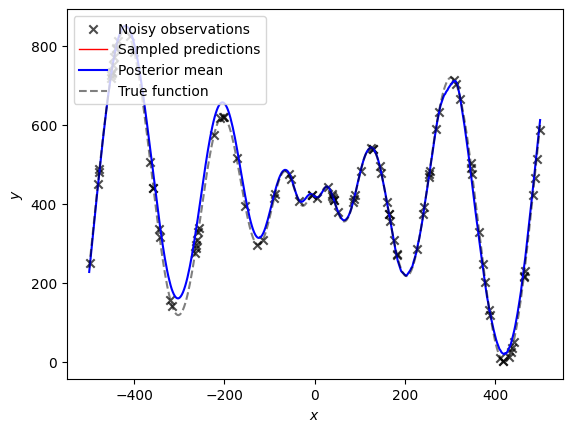

4 Sine
5 Branin


In [24]:
rng_key, rng_key_predict = gpax.utils.get_keys()

for i,title in enumerate(titles):

  #Remove the line below if want to analyze all fucntions
  print(i, title)
  if title == 'Schwefel': #'Sine':

    print("handling the functions===>", title)
    model_list = gpax_equations_dict[f"{title}"]["model_list"]
    model_prior_list = gpax_equations_dict[f"{title}"]["model_prior_list"]

    for j,(m, mp) in enumerate(zip(model_list,model_prior_list)):
      # Initialize model
      print("model number", j)
      gp_model = gpax.ExactGP(1, kernel='Matern', mean_fn=m, mean_fn_prior=mp)

      # Run MCMC to obtain posterior samples
      gp_model.fit(rng_key, X_measured_list[i], y_measured_list[i], num_warmup=NUM_WARMUP, num_samples=NUM_SAMPLES)

      # Get GP prediction
      posterior_mean, f_samples = gp_model.predict(rng_key_predict, X_unmeasured_list[i], n=200)

      # Plot results
      _, ax = plt.subplots(dpi=100)
      ax.set_xlabel("$x$")
      ax.set_ylabel("$y$")
      ax.scatter(X_measured_list[i], y_measured_list[i], marker='x', c='k', zorder=1, label="Noisy observations", alpha=0.7)
      for y1 in f_samples:
          ax.plot(X_unmeasured_list[i], y1.mean(0), lw=.1, zorder=0, c='r', alpha=.1)
      l, = ax.plot(X_unmeasured_list[i], f_samples[0].mean(0), lw=1, c='r', alpha=1, label="Sampled predictions")
      ax.plot(X_unmeasured_list[i], posterior_mean, lw=1.5, zorder=1, c='b', label='Posterior mean')

      ax.plot(X_unmeasured_list[i], ground_truth_list[i], c='k', linestyle='--', label='True function', alpha=0.5)
      ax.legend(loc='upper left')
      l.set_alpha(0)
      plt.show()


In [25]:


# # Plot results
# truefunc = func(X_unmeasured)
# seed_points = 15
# plt.figure(dpi=100)
# plt.scatter(X_measured[seed_points:], y_measured[seed_points:], c=jnp.arange(1, len(X_measured[seed_points:])+1),
#             cmap='viridis', label="Sampled points", zorder=1)
# cbar = plt.colorbar(label="Exploration step")
# cbar_ticks = np.arange(2, len(X_measured[seed_points:]) + 1, 2)
# cbar.set_ticks(cbar_ticks)
# plt.scatter(X_measured[:seed_points], y_measured[:seed_points], marker='x', s=64,
#             c='k', label="Seed points", zorder=1)
# plt.plot(X_unmeasured, truefunc, c='k', label='True function', zorder=0)
# plt.plot(X_unmeasured, posterior_mean, '--', c='red', label='Posterior mean', zorder=0)

# plt.fill_between(X_unmeasured, posterior_mean - f_samples.std((0,1)), posterior_mean + f_samples.std((0,1)),
#                         color='r', alpha=0.2, label="Model uncertainty", zorder=0)
# plt.xlabel("$x$", fontsize=12)
# plt.ylabel("$y$", fontsize=12)
# plt.legend(fontsize=9)
# plt.show()

# Next Active learning